# Function Transformer

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r"C:\Users\harsh\Downloads\archive\loan.csv")        
df                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [23]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [24]:
q1 = df["CoapplicantIncome"].quantile(0.25)
q3= df["CoapplicantIncome"].quantile(0.75)
iqr = q3-q1

In [25]:
min_r = q1-(1.5*iqr)
max_r = q3+(1.5*iqr)
min_r, max_r

(np.float64(-3445.875), np.float64(5743.125))

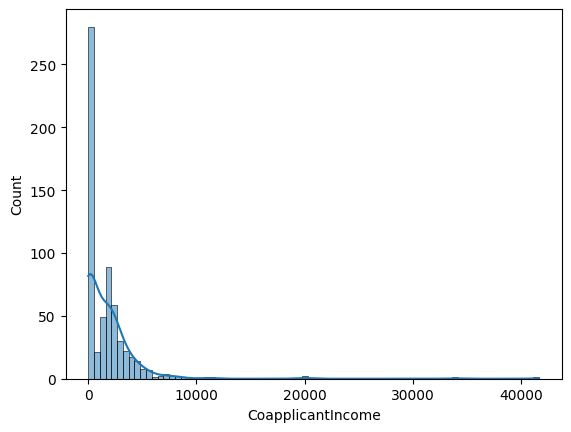

In [26]:
sns.histplot(df["CoapplicantIncome"], kde=True)
plt.show()

In [27]:
df = df[df["CoapplicantIncome"] <= max_r]

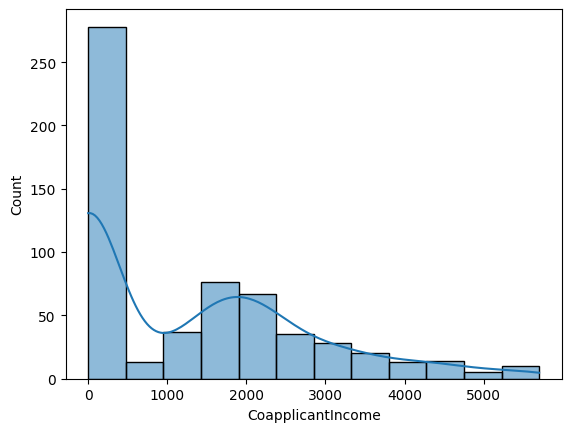

In [28]:
sns.histplot(df["CoapplicantIncome"], kde=True)
plt.show()

In [3]:
from sklearn.preprocessing import FunctionTransformer

In [11]:
ft = FunctionTransformer(func=np.log1p)

# log1p(x) = log(1 + x)
# ✔️ Normal log:
# log(x)

# ❌ Problem:
# log(0) = error ❌

# ✔️ Solution:
# log(1 + x)

In [12]:
ft.fit(df[["CoapplicantIncome"]])

,func,<ufunc 'log1p'>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None
,inv_kw_args,None


In [13]:
df["CoapplicantIncome_tf"] = ft.transform(df[["CoapplicantIncome"]])

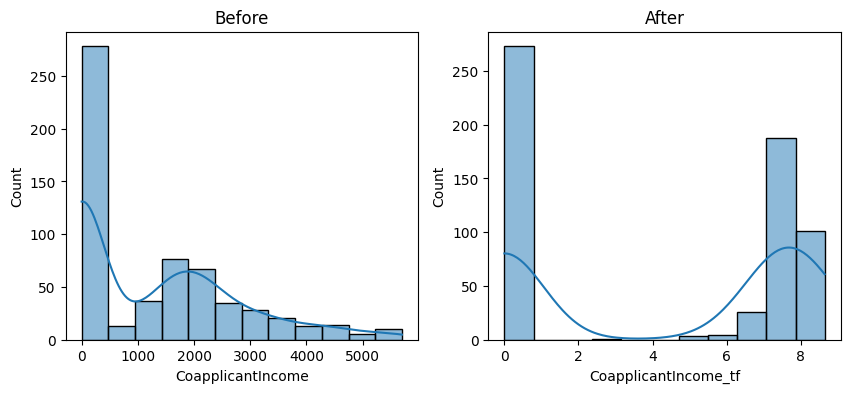

In [59]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df["CoapplicantIncome"], kde=True)
plt.title("Before")

plt.subplot(1,2,2)
sns.histplot(df["CoapplicantIncome_tf"], kde=True)
plt.title("After")

plt.show()

In [4]:
ft1 = FunctionTransformer(func = lambda x : x**2)   
ft1.fit(df[["CoapplicantIncome"]])
df["CoapplicantIncome_tf1"] = ft1.transform(df[["CoapplicantIncome"]])

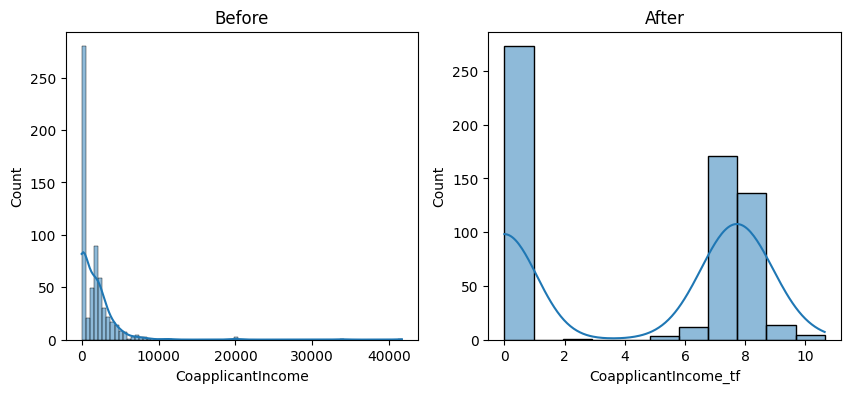

In [14]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df["CoapplicantIncome"], kde=True)
plt.title("Before")

plt.subplot(1,2,2)
sns.histplot(df["CoapplicantIncome_tf"], kde=True)
plt.title("After")

plt.show()